In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/processed/cleaned_salary_data.csv")

print(df.shape)

df.head()



(565, 9)


,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size,salary_in_usd
0,2020,MI,FT,Data Scientist,DE,0,DE,L,79833
1,2020,SE,FT,Machine Learning Scientist,JP,0,JP,S,260000
2,2020,SE,FT,Big Data Engineer,GB,50,GB,M,109024
3,2020,MI,FT,Product Data Analyst,HN,0,HN,S,20000
4,2020,SE,FT,Machine Learning Engineer,US,50,US,L,150000


In [43]:
X = df.drop(columns=["salary_in_usd"])

y = df["salary_in_usd"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (565, 8)
y shape: (565,)


In [44]:
numeric_columns = [
    "work_year",
    "remote_ratio"
]

categorical_columns = [
    "experience_level",
    "employment_type",
    "job_title",
    "employee_residence",
    "company_location",
    "company_size"
]

handled_columns = numeric_columns + categorical_columns
unhandled_columns = sorted(set(X.columns) - set(handled_columns))

print(f"Unhandled columns: {unhandled_columns}")

Unhandled columns: []


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (452, 8)
X_test shape: (113, 8)
y_train shape: (452,)
y_test shape: (113,)


In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_columns
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [47]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [48]:
model_pipeline.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


# 10. Extract Feature Names


In [49]:
feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()

print(f"Number of transformed features: {len(feature_names)}")

feature_names[:20]

Number of transformed features: 152


array(['num__work_year', 'num__remote_ratio', 'cat__experience_level_EN',
       'cat__experience_level_EX', 'cat__experience_level_MI',
       'cat__experience_level_SE', 'cat__employment_type_CT',
       'cat__employment_type_FL', 'cat__employment_type_FT',
       'cat__employment_type_PT', 'cat__job_title_AI Scientist',
       'cat__job_title_Analytics Engineer',
       'cat__job_title_Applied Data Scientist',
       'cat__job_title_Applied Machine Learning Scientist',
       'cat__job_title_BI Data Analyst',
       'cat__job_title_Big Data Architect',
       'cat__job_title_Big Data Engineer',
       'cat__job_title_Business Data Analyst',
       'cat__job_title_Cloud Data Engineer',
       'cat__job_title_Computer Vision Engineer'], dtype=object)

In [50]:
linear_model = model_pipeline.named_steps["model"]

coefficients = linear_model.coef_
intercept = linear_model.intercept_

print(f"Number of coefficients: {len(coefficients)}")
print(f"Intercept: {intercept}")

Number of coefficients: 152
Intercept: 83871.35906361302


In [51]:
coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coefficient_df["absolute_coefficient"] = coefficient_df["coefficient"].abs()

coefficient_df["direction"] = np.where(
    coefficient_df["coefficient"] >= 0,
    "positive",
    "negative"
)

coefficient_df.head()

,feature,coefficient,absolute_coefficient,direction
0,num__work_year,13.228014,13.228014,positive
1,num__remote_ratio,925.047503,925.047503,positive
2,cat__experience_level_EN,-50106.590272,50106.590272,negative
3,cat__experience_level_EX,75393.984280,75393.984280,positive
4,cat__experience_level_MI,-24342.289156,24342.289156,negative


In [52]:
top_positive=coefficient_df.sort_values(by='coefficient',ascending=False).head(15)
print("Top 15 positive coefficients:",top_positive)

Top 15 positive coefficients:                                                feature    coefficient  \
13   cat__job_title_Applied Machine Learning Scientist  274059.056303   
23                  cat__job_title_Data Analytics Lead  231512.807322   
35               cat__job_title_Financial Data Analyst  138373.008340   
51              cat__job_title_Principal Data Engineer  131099.876040   
67                          cat__employee_residence_CZ  121157.003957   
89                          cat__employee_residence_MY   84869.849920   
72                          cat__employee_residence_ES   79865.235400   
6                              cat__employment_type_CT   78231.441599   
18                  cat__job_title_Cloud Data Engineer   76143.377820   
3                             cat__experience_level_EX   75393.984280   
64                          cat__employee_residence_CH   69884.310412   
103                         cat__employee_residence_US   68476.026932   
127                  

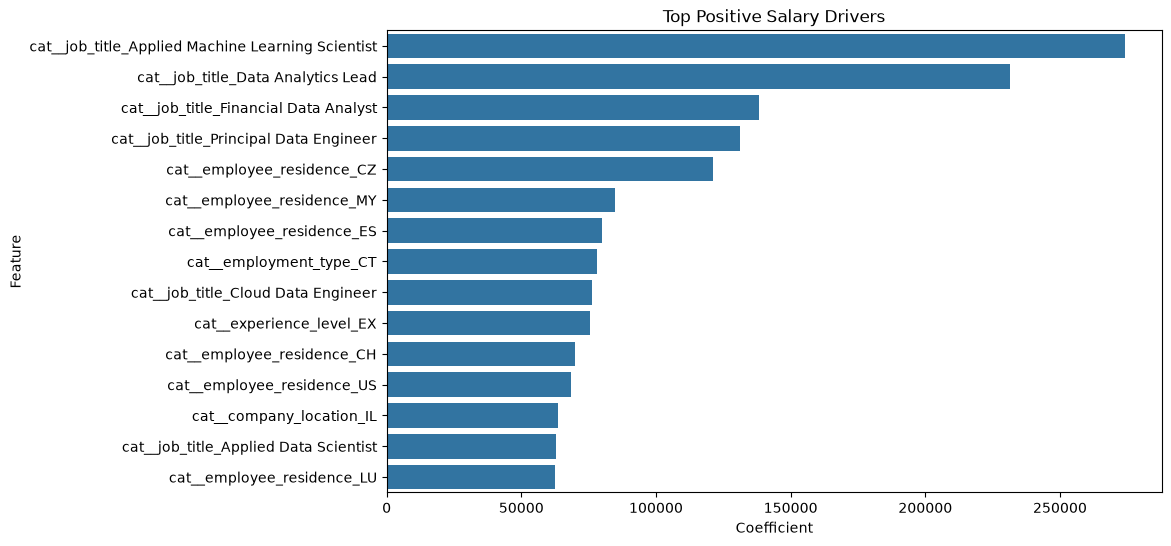

In [53]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_positive,
    x="coefficient",
    y="feature"
)

plt.title("Top Positive Salary Drivers")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

In [54]:
top_negative=coefficient_df.sort_values(by='coefficient',ascending=True).head(15)
print("Top 15 negative coefficients:",top_negative)

Top 15 negative coefficients:                                      feature    coefficient  \
61                cat__employee_residence_BO -280656.872069   
101               cat__employee_residence_TN -239378.010410   
55       cat__job_title_Staff Data Scientist -139061.784746   
115                 cat__company_location_CZ -118221.006452   
49               cat__job_title_NLP Engineer -111716.811003   
38   cat__job_title_Head of Machine Learning  -77943.806535   
120                 cat__company_location_ES  -75080.327612   
34       cat__job_title_Finance Data Analyst  -64023.684996   
104               cat__employee_residence_VN  -63902.213680   
37       cat__job_title_Head of Data Science  -63840.853729   
144                 cat__company_location_SG  -60044.171340   
7                    cat__employment_type_FL  -58281.605505   
53       cat__job_title_Product Data Analyst  -52263.524260   
110                 cat__company_location_BR  -51698.000076   
39          cat__job_titl

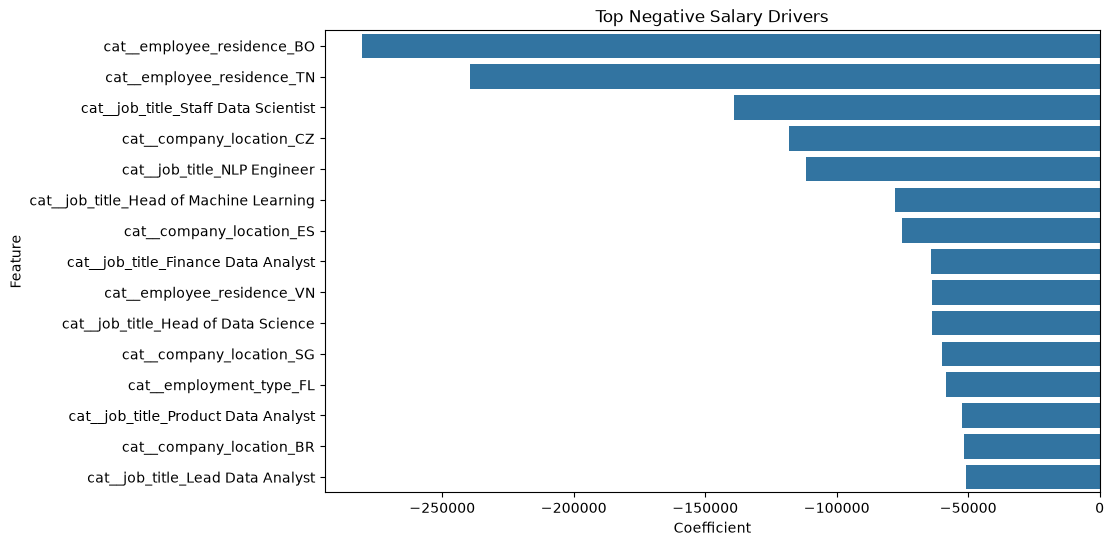

In [61]:
plt.figure(figsize=[10,6])

sns.barplot(
    data=top_negative,
    x="coefficient",
    y="feature"
)

plt.title("Top Negative Salary Drivers")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()



In [62]:
top_absolute = coefficient_df.sort_values(
    by="absolute_coefficient",
    ascending=False
).head(20)

top_absolute

,feature,coefficient,absolute_coefficient,direction
61,cat__employee_residence_BO,-280656.872069,280656.872069,negative
13,cat__job_title_Applied Machine Learning Scientist,274059.056303,274059.056303,positive
101,cat__employee_residence_TN,-239378.010410,239378.010410,negative
23,cat__job_title_Data Analytics Lead,231512.807322,231512.807322,positive
55,cat__job_title_Staff Data Scientist,-139061.784746,139061.784746,negative
35,cat__job_title_Financial Data Analyst,138373.008340,138373.008340,positive
51,cat__job_title_Principal Data Engineer,131099.876040,131099.876040,positive
67,cat__employee_residence_CZ,121157.003957,121157.003957,positive
115,cat__company_location_CZ,-118221.006452,118221.006452,negative
49,cat__job_title_NLP Engineer,-111716.811003,111716.811003,negative


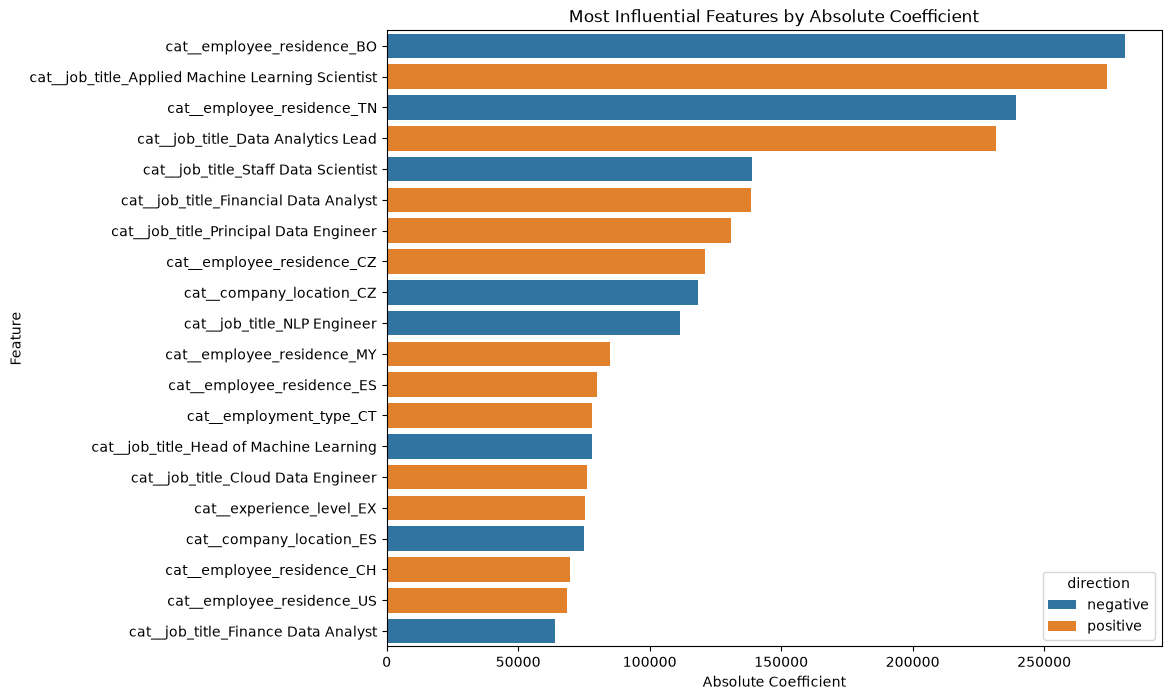

In [64]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_absolute,
    x="absolute_coefficient",
    y="feature",
    hue="direction"
)

plt.title("Most Influential Features by Absolute Coefficient")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.show()

In [65]:
print(f"Model intercept: {intercept:.2f}")

Model intercept: 83871.36


## Intercept Interpretation

The intercept is the baseline value `b` in the Linear Regression equation:

ŷ = wᵀx + b

Because this model uses scaled numeric features and one-hot encoded categorical features, the intercept should not be interpreted as the salary of a real person.

It is the model's mathematical baseline after preprocessing.

In [66]:
sample_index = 0

sample_input = X_test.iloc[[sample_index]]
sample_actual = y_test.iloc[sample_index]
sample_prediction = model_pipeline.predict(sample_input)[0]
sample_error = sample_actual - sample_prediction

print("Sample input:")
display(sample_input)

print(f"Actual salary: {sample_actual:.2f}")
print(f"Predicted salary: {sample_prediction:.2f}")
print(f"Error: {sample_error:.2f}")

Sample input:


,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
538,2022,SE,FT,Data Analyst,US,100,US,M


Actual salary: 80000.00
Predicted salary: 121606.40
Error: -41606.40


In [67]:
print("Linear Regression equation:")
print("ŷ = wᵀx + b")

print(f"Number of weights/features: {len(coefficients)}")
print(f"Intercept b: {intercept:.2f}")

Linear Regression equation:
ŷ = wᵀx + b
Number of weights/features: 152
Intercept b: 83871.36


## Hyperplane Interpretation

Linear Regression learns a hyperplane in feature space.

Each transformed feature becomes one axis.

The coefficient vector `w` controls the orientation of the hyperplane.

The intercept `b` shifts the hyperplane up or down.

The prediction is calculated as:

ŷ = wᵀx + b

In this project:

- `x` is the transformed salary feature vector
- `w` is the learned coefficient vector
- `b` is the model intercept
- `ŷ` is the predicted salary in USD

## Explainability Summary

1. Linear Regression is interpretable because every transformed feature has a coefficient.
2. Positive coefficients increase the predicted salary.
3. Negative coefficients decrease the predicted salary.
4. Coefficients should be interpreted as associations, not guaranteed causes.
5. One-hot encoded features represent category effects.
6. Scaled numeric features represent changes in standardized units.
7. The model learned a hyperplane represented by:

ŷ = wᵀx + b